In [ ]:
# ============================================================
# 安装 d2l 库（《动手学深度学习》工具库）
# ============================================================
# --no-deps: 不安装依赖包，避免版本冲突
# --quiet: 静默安装，减少输出信息
!pip install d2l --no-deps --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 6.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 导入必要的库
# ============================================================
import math  # 数学运算
import torch  # PyTorch深度学习框架
from torch import nn  # 神经网络模块
from d2l import torch as d2l  # 《动手学深度学习》工具库

# ============================================================
# 加载PTB数据集
# ============================================================
# 配置数据加载参数
batch_size = 512           # 批次大小：每次训练使用512个样本
max_window_size = 5        # 最大上下文窗口：左右各看5个词
num_noise_words = 5        # 负采样数量：每个上下文词对应5个负样本

# 加载数据
# data_iter: 数据迭代器，用于训练循环
# vocab: 词表对象，用于词和索引的转换
# 这个函数整合了：读取数据、构建词表、下采样、生成训练对、负采样等所有步骤
data_iter, vocab = d2l.load_data_ptb(batch_size, max_window_size,
                                     num_noise_words)

# 数据格式说明：
# 每个批次包含4个张量：
# - centers: 中心词索引，形状 (batch_size, 1)
# - contexts_negatives: 上下文词+负样本，形状 (batch_size, max_len)
# - masks: 掩码，标记有效位置，形状 (batch_size, max_len)
# - labels: 标签，1表示正样本，0表示负样本，形状 (batch_size, max_len)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# ============================================================
# Embedding 层演示
# ============================================================
# Embedding层是词嵌入的核心组件
# 作用：将整数索引转换为稠密的向量表示

# 创建一个Embedding层
# 参数说明：
#   - num_embeddings=20: 词表大小（可以存储20个不同的词）
#   - embedding_dim=4: 词向量维度（每个词用4维向量表示）
# 
# 内部结构：
#   维护一个权重矩阵，形状为 (num_embeddings, embedding_dim)
#   即 (20, 4)，每一行是一个词的向量
embed = nn.Embedding(num_embeddings=20, embedding_dim=4)

# 打印参数信息
print(f'Parameter embedding_weight ({embed.weight.shape}, '
      f'dtype={embed.weight.dtype})')

# 输出说明：
# - shape: torch.Size([20, 4])
#   * 20行（对应20个词）
#   * 4列（每个词的向量维度）
# - dtype: 通常是 torch.float32
#   * 每个权重是32位浮点数

# Embedding层的工作原理：
# 本质上是查表操作，非常高效
# embed(索引) -> 返回权重矩阵的对应行


Parameter embedding_weight (torch.Size([20, 4]), dtype=torch.float32)


In [ ]:
# ============================================================
# Embedding 层的使用示例
# ============================================================
# 创建一个输入张量，包含词的索引
# 形状: (2, 3) - 2个句子，每个句子3个词
x = torch.tensor([[1, 2, 3],   # 第一个句子：词索引为1、2、3
                  [4, 5, 6]])  # 第二个句子：词索引为4、5、6

# 通过Embedding层转换
# 输入: (2, 3) - 整数索引
# 输出: (2, 3, 4) - 每个索引变成4维向量
result = embed(x)

# 输出形状解释：
# - 维度0: 批次大小 = 2（2个句子）
# - 维度1: 序列长度 = 3（每个句子3个词）
# - 维度2: 词向量维度 = 4（每个词用4维向量表示）

# 等价操作（查表）：
# result[0, 0] = embed.weight[1]  # 第1个句子的第1个词（索引1）的向量
# result[0, 1] = embed.weight[2]  # 第1个句子的第2个词（索引2）的向量
# result[1, 0] = embed.weight[4]  # 第2个句子的第1个词（索引4）的向量
# ...

result


tensor([[[ 1.1342, -0.7157,  1.1117, -1.2536],
         [-0.5551, -0.7216, -0.1482, -0.1871],
         [-1.0712, -1.7578,  0.6270,  1.0984]],

        [[ 1.2918, -1.6295, -1.8775, -1.1029],
         [ 0.5553, -0.2450, -0.7205,  0.5740],
         [-0.1275, -0.2634, -1.1191,  1.1296]]], grad_fn=<EmbeddingBackward0>)

In [ ]:
def skip_gram(center, contexts_and_negatives, embed_v, embed_u):
    """Skip-gram 模型的前向传播
    
    核心思想：
        计算中心词与上下文词/负样本之间的相似度
        
    数学原理：
        相似度 = 中心词向量 · 上下文词向量（点积）
        
        对于每对词 (center, context):
            score = v_center · u_context
            
        点积越大，说明两个词越相似（应该经常一起出现）
    
    模型架构：
        使用双Embedding矩阵：
        - embed_v: 中心词的Embedding（输入层）
        - embed_u: 上下文词的Embedding（输出层）
    
    为什么用两个Embedding？
        - 理论上可以共享，但实践中分开效果更好
        - 中心词和上下文词在训练中扮演不同角色
        - 最终只保留 embed_v 作为词向量
    
    参数:
        center: 中心词索引，形状 (batch_size, 1)
        contexts_and_negatives: 上下文词+负样本索引，形状 (batch_size, max_len)
        embed_v: 中心词Embedding层
        embed_u: 上下文词Embedding层
        
    返回:
        pred: 预测分数，形状 (batch_size, 1, max_len)
              每个分数表示中心词与对应词的相似度
    """
    # 步骤1: 获取中心词向量
    # center: (batch_size, 1) -> v: (batch_size, 1, embed_dim)
    v = embed_v(center)
    
    # 步骤2: 获取上下文词/负样本向量
    # contexts_and_negatives: (batch_size, max_len) -> u: (batch_size, max_len, embed_dim)
    u = embed_u(contexts_and_negatives)
    
    # 步骤3: 计算点积（批量矩阵乘法）
    # torch.bmm: Batch Matrix Multiplication
    # v: (batch, 1, dim)
    # u.permute(0, 2, 1): (batch, max_len, dim) -> (batch, dim, max_len)
    # 结果: (batch, 1, max_len)
    #
    # 解释：
    # 对于批次中的每个样本：
    #   v 是 (1, dim) 的向量（中心词）
    #   u^T 是 (dim, max_len) 的矩阵（所有上下文词/负样本）
    #   v × u^T = (1, max_len)：中心词与每个词的相似度分数
    pred = torch.bmm(v, u.permute(0, 2, 1))
    
    return pred


In [ ]:
# ============================================================
# 测试 skip_gram 函数的输出形状
# ============================================================
# 创建测试输入
# center: (2, 1) - 2个样本，每个样本1个中心词
# contexts_and_negatives: (2, 4) - 2个样本，每个样本4个词（上下文+负样本）

test_output = skip_gram(
    torch.ones((2, 1), dtype=torch.long),   # 中心词索引（全为1用于测试）
    torch.ones((2, 4), dtype=torch.long),   # 上下文词+负样本索引（全为1）
    embed,                                   # 中心词Embedding
    embed                                    # 上下文词Embedding（这里用同一个测试）
)

# 输出形状
test_output.shape

# 预期输出: torch.Size([2, 1, 4])
# 解释:
#   - 维度0: 批次大小 = 2（2个样本）
#   - 维度1: 中心词数量 = 1（每个样本1个中心词）
#   - 维度2: 上下文词+负样本数量 = 4（每个中心词对应4个词）
#
# 含义：
#   对于每个样本，有1个中心词，需要预测4个词（上下文或负样本）的概率
#   输出的每个值是相似度分数（未归一化）


torch.Size([2, 1, 4])

In [ ]:
class SigmoidBCELoss(nn.Module):
    """带掩码的Sigmoid二元交叉熵损失
    
    为什么需要这个损失函数？
        Skip-gram的负采样本质上是一个二分类问题：
        - 正样本（真实上下文词）：标签=1
        - 负样本（随机采样的词）：标签=0
        
        对于每对 (中心词, 候选词)，预测它们是否真的一起出现
    
    二元交叉熵公式：
        BCE = -[y·log(σ(x)) + (1-y)·log(1-σ(x))]
        
        其中：
        - x: 预测分数（相似度）
        - y: 真实标签（1或0）
        - σ: Sigmoid函数，将分数转换为概率
    
    为什么需要掩码（mask）？
        - 批次中不同样本的序列长度不同
        - 较短的序列会被填充（padding）
        - 掩码标记哪些位置是有效的，哪些是填充
        - 损失只在有效位置计算，忽略填充位置
    
    与标准BCE的区别：
        - 标准BCE对所有位置平等对待
        - 这里使用掩码加权，只关注有效位置
    """
    
    def __init__(self):
        super().__init__()

    def forward(self, inputs, target, mask=None):
        """计算带掩码的二元交叉熵损失
        
        参数:
            inputs: 预测分数（logits），形状 (batch_size, max_len)
                   未经过sigmoid的原始分数
            target: 真实标签，形状 (batch_size, max_len)
                   1表示正样本，0表示负样本
            mask: 掩码，形状 (batch_size, max_len)
                 1表示有效位置，0表示填充位置
                 
        返回:
            损失值，形状 (batch_size,)
            每个样本的平均损失
        """
        # 使用 binary_cross_entropy_with_logits
        # 优点：
        #   1. 数值稳定性更好（内部合并了sigmoid和BCE计算）
        #   2. 避免了显式计算sigmoid可能导致的数值问题
        #
        # 参数说明：
        #   - inputs: 预测的logits（未归一化的分数）
        #   - target: 真实标签（0或1）
        #   - weight=mask: 使用掩码作为权重
        #       * 有效位置(mask=1): 正常计算损失
        #       * 填充位置(mask=0): 损失被置为0，不参与计算
        #   - reduction="none": 不自动求和/平均，保留每个位置的损失
        out = nn.functional.binary_cross_entropy_with_logits(
            inputs, target, weight=mask, reduction="none")
        
        # 按样本维度求平均（dim=1）
        # 每个样本返回一个损失值
        return out.mean(dim=1)

# 创建损失函数实例
loss = SigmoidBCELoss()


In [ ]:
# ============================================================
# 测试损失函数
# ============================================================
# 创建测试数据
# 批次大小=2，每个样本4个预测

# 预测分数（logits）
pred = torch.tensor([[1.1, -2.2, 3.3, -4.4]] * 2)
# 两个样本的预测相同：[1.1, -2.2, 3.3, -4.4]

# 真实标签
label = torch.tensor([[1.0, 0.0, 0.0, 0.0],   # 样本1: 第1个是正样本，其余是负样本
                      [0.0, 1.0, 0.0, 0.0]])  # 样本2: 第2个是正样本，其余是负样本

# 掩码
mask = torch.tensor([[1, 1, 1, 1],   # 样本1: 4个位置都有效
                     [1, 1, 0, 0]])  # 样本2: 只有前2个位置有效，后2个是填充

# 计算损失
# loss(pred, label, mask) 返回每个样本的平均损失
# * mask.shape[1]: 乘以序列长度（4）
# / mask.sum(axis=1): 除以有效位置数量
#
# 为什么要做这个调整？
#   loss函数内部已经对所有位置（包括填充）求了平均
#   但我们只想对有效位置求平均
#   
#   调整公式：
#   归一化损失 = (平均损失 × 总位置数) / 有效位置数
#
# 对于样本1: 有效位置=4，归一化因子=4/4=1
# 对于样本2: 有效位置=2，归一化因子=4/2=2

loss(pred, label, mask) * mask.shape[1] / mask.sum(axis=1)

# 预期输出:
# tensor([...])  # 两个样本的归一化损失


tensor([0.9352, 1.8462])

In [ ]:
# ============================================================
# 手动验证损失计算
# ============================================================
def sigmd(x):
    """计算Sigmoid BCE损失（单个值）
    
    公式推导：
        对于二元交叉熵：
        BCE = -[y·log(σ(x)) + (1-y)·log(1-σ(x))]
        
        当 y=1（正样本）：
        BCE = -log(σ(x)) = -log(1/(1+e^(-x))) = log(1+e^(-x))
        
        当 y=0（负样本）：
        BCE = -log(1-σ(x)) = -log(e^(-x)/(1+e^(-x))) = log(1+e^x)
        
        为了数值稳定性，使用以下形式：
        BCE = log(1 + exp(-|x|)) + max(0, -x)
        
        但这里为了简单，使用原始形式
    
    参数:
        x: 预测分数（logit）
        
    返回:
        损失值（假设标签为1）
    """
    return -math.log(1 / (1 + math.exp(-x)))

# 验证样本1的损失（4个有效位置）
# 预测: [1.1, -2.2, 3.3, -4.4]
# 标签: [1,   0,    0,   0  ]
#
# 位置0: 正样本(标签=1)，预测=1.1
#   损失 = -log(sigmoid(1.1)) = sigmd(1.1)
# 位置1: 负样本(标签=0)，预测=-2.2
#   损失 = -log(1-sigmoid(-2.2)) = -log(sigmoid(2.2)) = sigmd(2.2)
# 位置2: 负样本(标签=0)，预测=3.3
#   损失 = -log(1-sigmoid(3.3)) = sigmd(-3.3)
# 位置3: 负样本(标签=0)，预测=-4.4
#   损失 = -log(1-sigmoid(-4.4)) = sigmd(4.4)

sample1_loss = (sigmd(1.1) + sigmd(2.2) + sigmd(-3.3) + sigmd(4.4)) / 4
print(f'{sample1_loss:.4f}')

# 验证样本2的损失（只有前2个位置有效）
# 预测: [1.1, -2.2, ...]
# 标签: [0,   1,   ...]
# 掩码: [1,   1,   0, 0]  # 只计算前2个
#
# 位置0: 负样本(标签=0)，预测=1.1
#   损失 = sigmd(-1.1)
# 位置1: 正样本(标签=1)，预测=-2.2
#   损失 = sigmd(-2.2)

sample2_loss = (sigmd(-1.1) + sigmd(-2.2)) / 2
print(f'{sample2_loss:.4f}')

# 这两个值应该与上一个单元格的输出一致


0.9352
1.8462


In [ ]:
# ============================================================
# 定义完整的Skip-gram模型
# ============================================================
# 设置词向量维度
embed_size = 100  # 每个词用100维向量表示
# 工业界常用配置：
# - 小数据集：50-100维
# - 中等数据集：100-200维
# - 大数据集：200-300维

# 构建模型：使用nn.Sequential包装两个Embedding层
# 为什么用Sequential？
#   虽然两个Embedding层不是顺序执行的，但这样包装便于管理
#   可以通过 net[0] 和 net[1] 分别访问
net = nn.Sequential(
    # 第一个Embedding：中心词向量（输入层）
    # 这是我们最终要使用的词向量
    nn.Embedding(num_embeddings=len(vocab),  # 词表大小
                 embedding_dim=embed_size),   # 向量维度
    
    # 第二个Embedding：上下文词向量（输出层）
    # 用于计算相似度，训练后通常只保留第一个
    nn.Embedding(num_embeddings=len(vocab),
                 embedding_dim=embed_size)
)

# 模型结构说明：
# net[0]: 中心词Embedding，权重形状 (vocab_size, 100)
# net[1]: 上下文词Embedding，权重形状 (vocab_size, 100)
# 总参数量: 2 × vocab_size × 100

# 使用方式：
# 在 skip_gram 函数中：
#   - net[0] 用于编码中心词
#   - net[1] 用于编码上下文词/负样本


In [ ]:
def train(net, data_iter, lr, num_epochs, device=d2l.try_gpu()):
    """训练Skip-gram词嵌入模型
    
    训练流程：
    1. 初始化权重
    2. 设置优化器
    3. 创建可视化工具
    4. 训练循环：
       - 前向传播
       - 计算损失
       - 反向传播
       - 更新参数
    5. 记录和可视化训练过程
    
    参数:
        net: Skip-gram模型（包含两个Embedding层）
        data_iter: 数据迭代器
        lr: 学习率
        num_epochs: 训练轮数
        device: 计算设备（CPU或GPU）
    """
    
    # ========================================================
    # 步骤1: 权重初始化
    # ========================================================
    def init_weights(m):
        """Xavier均匀初始化
        
        为什么需要好的初始化？
        - 如果权重全为0：所有词的向量相同，无法学习
        - 如果权重太大：梯度爆炸
        - 如果权重太小：梯度消失
        
        Xavier初始化：
        从均匀分布 U(-a, a) 采样，其中 a = sqrt(6 / (fan_in + fan_out))
        适用于线性层和Embedding层
        """
        if type(m) == nn.Embedding:
            nn.init.xavier_uniform_(m.weight)
    
    # 应用初始化到模型的所有Embedding层
    net.apply(init_weights)
    
    # ========================================================
    # 步骤2: 将模型移到目标设备（GPU或CPU）
    # ========================================================
    net = net.to(device)
    
    # ========================================================
    # 步骤3: 设置优化器
    # ========================================================
    # Adam: 自适应学习率优化器
    # 优点：
    #   - 自动调整每个参数的学习率
    #   - 对学习率不敏感
    #   - 收敛速度快
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    
    # ========================================================
    # 步骤4: 创建动画工具（用于实时可视化训练过程）
    # ========================================================
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs])
    
    # ========================================================
    # 步骤5: 初始化累加器（记录损失和样本数）
    # ========================================================
    # metric[0]: 累计损失
    # metric[1]: 处理的样本数
    metric = d2l.Accumulator(2)
    
    # ========================================================
    # 步骤6: 训练循环
    # ========================================================
    for epoch in range(num_epochs):
        timer = d2l.Timer()  # 计时器
        num_batches = len(data_iter)  # 批次总数
        
        # 遍历所有批次
        for i, batch in enumerate(data_iter):
            # ----------------------------------------------------
            # 6.1 数据准备
            # ----------------------------------------------------
            optimizer.zero_grad()  # 清空梯度
            
            # 将所有数据移到设备（GPU/CPU）
            center, context_negative, mask, label = [
                data.to(device) for data in batch]

            # ----------------------------------------------------
            # 6.2 前向传播
            # ----------------------------------------------------
            # 计算预测分数
            # pred: (batch_size, 1, max_len)
            pred = skip_gram(center, context_negative, net[0], net[1])
            
            # ----------------------------------------------------
            # 6.3 计算损失
            # ----------------------------------------------------
            # reshape: (batch_size, 1, max_len) -> (batch_size, max_len)
            # 以匹配label的形状
            
            # 损失计算步骤：
            # a) 计算带掩码的BCE损失
            # b) 除以有效位置数，得到每个样本的平均损失
            # c) 乘以序列长度，进行归一化
            l = (loss(pred.reshape(label.shape).float(), label.float(), mask)
                     / mask.sum(axis=1) * mask.shape[1])
            
            # ----------------------------------------------------
            # 6.4 反向传播
            # ----------------------------------------------------
            l.sum().backward()  # 计算梯度（对批次内所有样本的损失求和）
            
            # ----------------------------------------------------
            # 6.5 参数更新
            # ----------------------------------------------------
            optimizer.step()  # 根据梯度更新参数
            
            # ----------------------------------------------------
            # 6.6 记录指标
            # ----------------------------------------------------
            metric.add(l.sum(), l.numel())  # 累加损失和样本数
            
            # ----------------------------------------------------
            # 6.7 定期更新可视化
            # ----------------------------------------------------
            # 每隔一定批次或最后一批更新一次
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                # 计算当前平均损失
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[1],))
    
    # ========================================================
    # 步骤7: 打印训练总结
    # ========================================================
    print(f'loss {metric[0] / metric[1]:.3f}, '
          f'{metric[1] / timer.stop():.1f} tokens/sec on {str(device)}')
    
    # 输出说明：
    # - loss: 最终的平均损失
    # - tokens/sec: 训练速度（每秒处理的词数）
    # - device: 使用的设备（cuda:0 或 cpu）


loss 0.410, 53008.3 tokens/sec on cpu


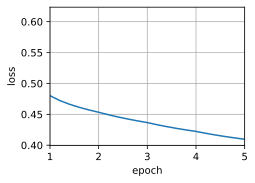

In [ ]:
# ============================================================
# 开始训练模型
# ============================================================
# 设置训练超参数
lr = 0.002          # 学习率：控制参数更新的步长
num_epochs = 5      # 训练轮数：遍历整个数据集的次数

# 训练参数说明：
# - 学习率 0.002: 对于Adam优化器，这是一个较好的起始值
#   * 太大：训练不稳定，损失震荡
#   * 太小：收敛太慢
# 
# - 训练轮数 5: 对于PTB数据集，5轮通常足够
#   * 太少：模型未充分学习
#   * 太多：可能过拟合，且时间成本高

# 执行训练
train(net, data_iter, lr, num_epochs)

# 训练过程中会显示：
# 1. 实时的损失曲线图
#    - x轴：epoch（训练轮数）
#    - y轴：loss（损失值）
#    - 预期：损失逐渐下降并趋于稳定
# 
# 2. 训练完成后打印：
#    - 最终损失值（越小越好，通常在0.4-0.6之间）
#    - 训练速度（tokens/sec，取决于硬件）
#    - 使用的设备（GPU或CPU）

# 训练完成后：
# - net[0].weight 包含学到的词向量（vocab_size × 100）
# - 每一行是一个词的100维向量表示
# - 这些向量捕捉了词的语义信息
#   相似的词会有相似的向量


In [ ]:
def get_similar_tokens(query_token, k, embed):
    """查找与查询词最相似的k个词
    
    相似度计算：使用余弦相似度
    
    余弦相似度公式：
        cos(θ) = (A · B) / (||A|| × ||B||)
        
    其中：
        - A · B: 向量点积（分子）
        - ||A||: 向量A的模（长度）
        - ||B||: 向量B的模（长度）
    
    余弦相似度的特性：
        - 范围：[-1, 1]
        - 1: 完全相同方向（最相似）
        - 0: 正交（无关）
        - -1: 完全相反方向
    
    为什么用余弦相似度而不是欧氏距离？
        - 余弦相似度关注方向，不受向量长度影响
        - 更适合高维空间的相似度计算
        - 词嵌入中，语义相似性主要体现在方向上
    
    参数:
        query_token: 查询词（字符串）
        k: 返回最相似的k个词
        embed: Embedding层（包含词向量）
        
    返回:
        打印与查询词最相似的k个词及其相似度
    """
    # ========================================================
    # 步骤1: 获取所有词向量
    # ========================================================
    # embed.weight: 形状 (vocab_size, embed_dim)
    # .data: 获取张量数据，不追踪梯度
    W = embed.weight.data
    
    # ========================================================
    # 步骤2: 获取查询词的向量
    # ========================================================
    # vocab[query_token]: 将词转换为索引
    # W[索引]: 获取该词的向量
    x = W[vocab[query_token]]
    
    # ========================================================
    # 步骤3: 计算余弦相似度
    # ========================================================
    # 公式: cos(θ) = (W × x) / (||W|| × ||x||)
    
    # 分子部分：W × x
    # torch.mv: 矩阵-向量乘法
    # W: (vocab_size, dim), x: (dim,) -> 结果: (vocab_size,)
    # 结果[i] = W[i] · x（第i个词与查询词的点积）
    numerator = torch.mv(W, x)
    
    # 分母部分：||W|| × ||x||
    # torch.sum(W * W, dim=1): 计算每个词向量的平方和
    # 结果: (vocab_size,)，每个词的向量长度平方
    # torch.sum(x * x): 查询词向量的长度平方（标量）
    # 相乘后开方得到分母，加1e-9防止除以0
    denominator = torch.sqrt(torch.sum(W * W, dim=1) *
                            torch.sum(x * x) + 1e-9)
    
    # 余弦相似度 = 分子 / 分母
    cos = numerator / denominator
    
    # ========================================================
    # 步骤4: 找出最相似的k个词
    # ========================================================
    # torch.topk: 返回最大的k个值及其索引
    # k=k+1: 多取一个，因为包含查询词自己
    # [1]: 只要索引，不要值
    topk = torch.topk(cos, k=k+1)[1].cpu().numpy().astype('int32')
    
    # ========================================================
    # 步骤5: 打印结果
    # ========================================================
    # topk[1:]: 跳过第一个（查询词自己）
    for i in topk[1:]:
        print(f'cosine sim={float(cos[i]):.3f}: {vocab.to_tokens(i)}')
    
    # 输出格式：
    # cosine sim=0.xxx: word
    # 相似度越高，说明两个词在语义上越接近

# ============================================================
# 测试：查找与 'chip' 最相似的3个词
# ============================================================
get_similar_tokens('chip', 3, net[0])

# 预期结果：
# 可能会出现与 'chip' 相关的词，如：
# - 技术类词汇：'intel', 'processor', 'computer'
# - 或其他在相似上下文中出现的词
#
# 注意：
# - 结果质量取决于训练质量和数据规模
# - PTB数据集较小，结果可能不完美
# - 更大的语料库（如维基百科）会得到更好的结果


cosine sim=0.688: microprocessor
cosine sim=0.662: intel
cosine sim=0.660: workstations
